# Supplementary Figure S3 arm-level CNV heatmap

This notebook generates the chromosome-arm-level copy-number summary heatmaps used for Supplementary Figure S3.

The workflow:
- loads Sequenza segment and ploidy/cellularity outputs
- aggregates CNt values across chromosome arms
- applies a 33% chromosome-arm coverage threshold
- summarizes gain/loss status relative to sample ploidy
- plots per-sample and per-patient arm-level heatmaps

This notebook also exports patient-specific event summary snippets used in the later manual assembly of phylogenetic summaries for Figure 4 and Figure S4.

In [ ]:
import numpy as np
import os
import pandas as pd
import seaborn as sns
import ast
import scipy.stats
from intervaltree import Interval, IntervalTree

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib as mpl  

pd.options.display.max_columns = 200
pd.options.display.max_rows = 200

In [ ]:
working_dir = 'PATH_TO_SEQUENZA_RESULTS'

os.chdir(working_dir)

temp_files = sorted([i for i in os.listdir(working_dir) if ('DS' not in i) and ('chromosome_views' not in i) \
                    and ('sequenza_segments' not in i)])

In [42]:
segment_dfs = {}

for sample_name in temp_files:
    
    sample_dir = working_dir + sample_name + '/' + sample_name + '_segments.txt'
    segment_dfs[sample_name] = pd.read_csv(sample_dir, sep='\t', low_memory=False) 

In [43]:
confints_cp_dfs = {}

for sample_name in temp_files:
    
    sample_dir = working_dir + sample_name + '/' + sample_name + '_confints_CP.txt'
    confints_cp_dfs[sample_name] = pd.read_csv(sample_dir, sep='\t', low_memory=False) 

In [44]:
cellularity_dict = {}
ploidy_dict = {}

for sample_name in confints_cp_dfs:
    
    if len(confints_cp_dfs[sample_name]) != 3:
        
        print(sample_name)
        
    cellularity_dict[sample_name] = confints_cp_dfs[sample_name].iloc[1]['cellularity']
    ploidy_dict[sample_name] = confints_cp_dfs[sample_name].iloc[1]['ploidy.estimate']

In [47]:
patient_id_list = []

for sample_id in cellularity_dict:
    
    if sample_id.split('_')[0] not in patient_id_list:
        
        patient_id_list.append(sample_id.split('_')[0])

In [49]:
p_id_split_dict = {p_id: {} for p_id in patient_id_list}

for key, value in cellularity_dict.items():
    
    for p_id in p_id_split_dict:
        
        if key.startswith(p_id):
            
            p_id_split_dict[p_id][key] = value
            
            break  

In [50]:
cellularity_dict_sorted_by_patient = {}

cellularity_dict_sorted_by_patient_w_subdict = {}

for p_id in p_id_split_dict:
    
    cellularity_dict_sorted_by_patient_w_subdict[p_id] = \
    {k:v for k,v in sorted(p_id_split_dict[p_id].items(), key=lambda item:item[1])}
    
    for sample_id in cellularity_dict_sorted_by_patient_w_subdict[p_id]:
        
        cellularity_dict_sorted_by_patient[sample_id] = cellularity_dict_sorted_by_patient_w_subdict[p_id][sample_id]

In [ ]:
new_sample_list = \
['RAP-001_65852_T',
 'RAP-001_65847_T',
 'RAP-002_14015_T',
 'RAP-002_14071_T',
 'RAP-002_14009_T',
 'RAP-002_14057_T',
 'RAP-002_14029_T',
 'RAP-003_69675_T',
 'RAP-003_69443_T',
 'RAP-003_69692_T',
 'RAP-004_70735_T',
 'RAP-004_70676_T',
 'RAP-004_70385_T',
 'RAP-004_70939_T',
 'RAP-004_70396_T',
 'RAP-004_70647_T',
 'RAP-004_70370_T',
 'RAP-004_70401_T',
 'RAP-005_179178_T',
 'RAP-005_179317_T',
 'RAP-005_179141_T',
 'RAP-005_179174_T',
 'RAP-005_179337_T',
 'RAP-005_179131_T',
 'RAP-005_179341_T',
 'RAP-006_150206_T',
 'RAP-006_150169_T',
 'RAP-006_150153_T',
 'RAP-006_150124_T',
 'RAP-006_150264_T',
 'RAP-006_150175_T',
 'RAP-006_150200_T',
 'RAP-006_150289_T',
 'RAP-006_150274_T',
 'RAP-006_150230_T',
 'RAP-006_150113_T',
 'RAP-006_150139_T',
 'RAP-006_150145_T',
 'RAP-007_245081_T',
 'RAP-007_245138_T',
 'RAP-007_244988_T',
 'RAP-007_244103_T',
 'RAP-007_245184_T',
 'RAP-007_244126_T',
 'RAP-007_245062_T',
 'RAP-007_244120_T',
 'RAP-007_245163_T',
 'RAP-007_245725_T']

In [54]:
temp_cell_ploid_plot_df_dict = {'sample_id': [s_id for s_id in cellularity_dict_sorted_by_patient if s_id in new_sample_list], \
                                'cellularity': [cellularity_dict_sorted_by_patient[s_id] for s_id in cellularity_dict_sorted_by_patient if s_id in new_sample_list], \
                                'ploidy': [ploidy_dict[s_id] for s_id in cellularity_dict_sorted_by_patient if s_id in new_sample_list]}

temp_cell_ploid_plot_df = pd.DataFrame.from_dict(temp_cell_ploid_plot_df_dict)

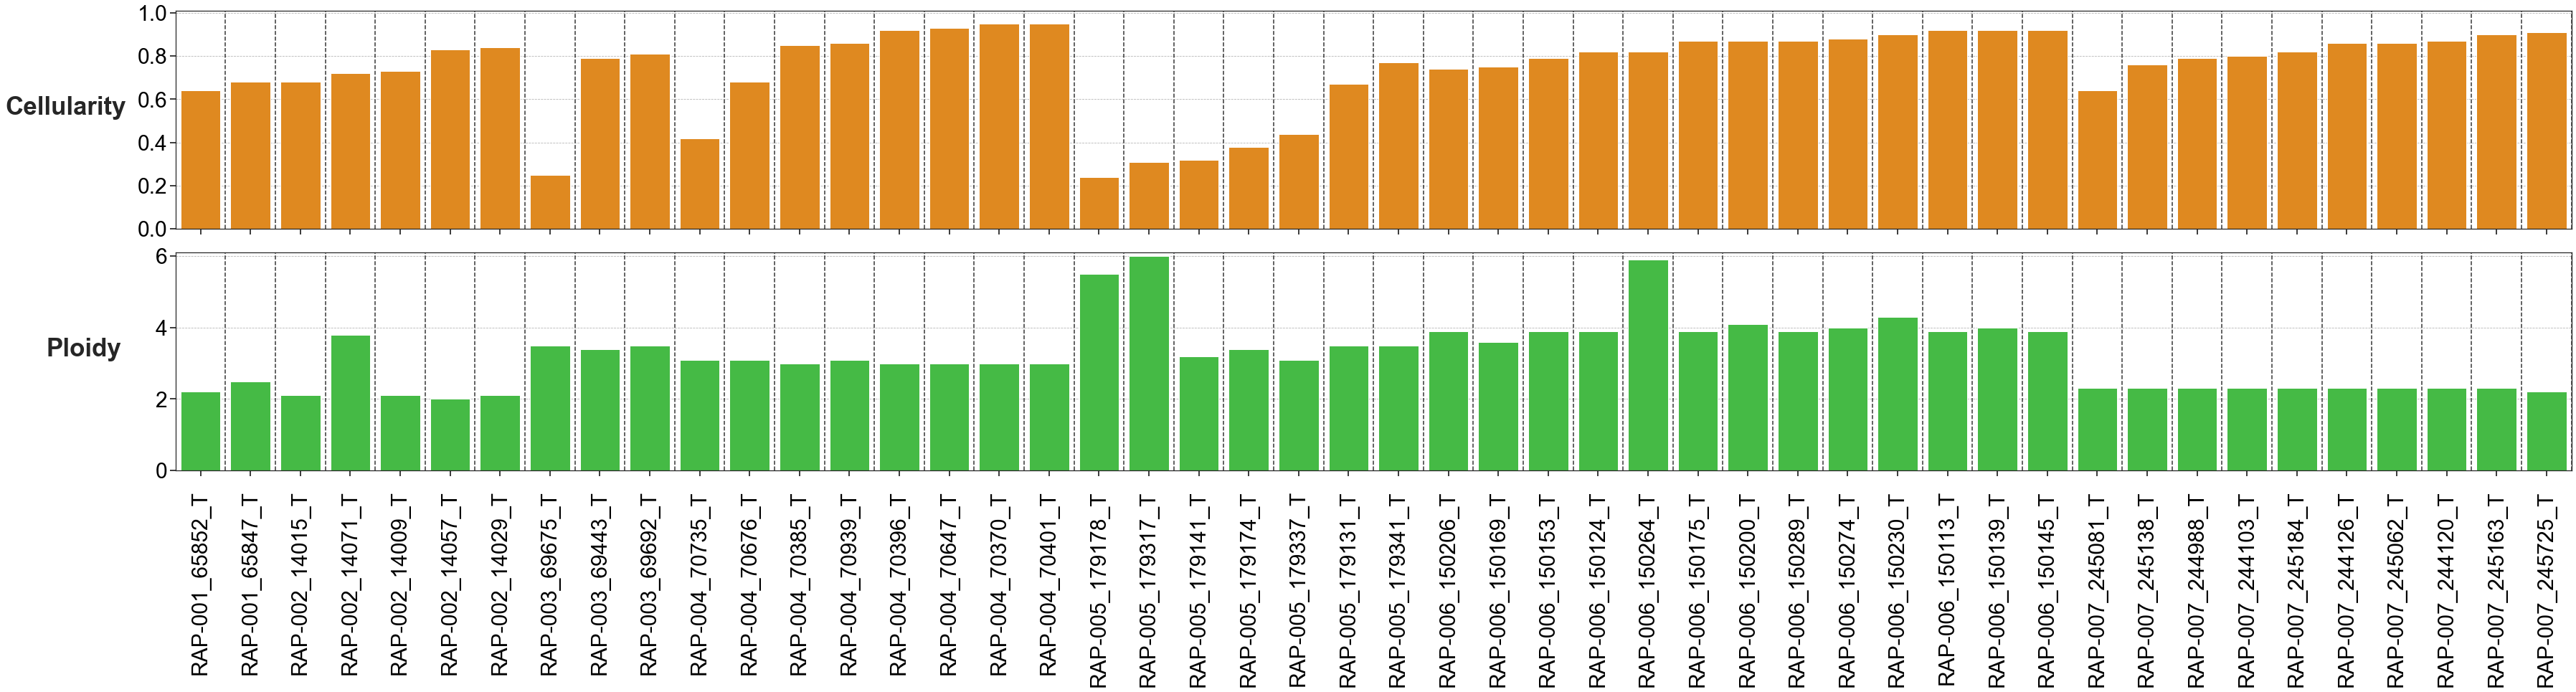

In [ ]:
# Setup plot appearance
sns.set(style='white', rc={"axes.facecolor": "white", "grid.color": "black"})

fig, axes = plt.subplots(2, 1, figsize=(50, 13.5), sharex=True)
palette_colors = ['darkorange', 'limegreen']

# Plot Deletion
ax = axes[0]
sns.barplot(x='sample_id', y=temp_cell_ploid_plot_df['cellularity'], data=temp_cell_ploid_plot_df, ax=ax, color=palette_colors[0])
ax.set_xlabel('')
ax.set_ylabel('Cellularity', weight='bold', labelpad=100, fontsize=35, rotation=0, ha='center')
ax.set_ylim(0, 1.01)
ax.set_yticks(np.arange(0, 1.01, 0.2))

ax.tick_params(axis='y', labelsize=30)
ax.tick_params(axis='x', labelsize=20, pad=20)
ax.tick_params(axis='both', which='both', length=8, width=1.5, direction='out', colors='black')

# y-axis tick mark settings
for tick in ax.yaxis.get_major_ticks():
    tick.tick1line.set_visible(True)
    tick.tick1line.set_linewidth(1.5)
    tick.tick1line.set_color('black')

for tick in ax.yaxis.get_minor_ticks():
    tick.tick1line.set_visible(True)
    tick.tick1line.set_linewidth(1.5)
    tick.tick1line.set_color('black')

# x-axis tick mark settings
for tick in ax.xaxis.get_major_ticks():
    tick.tick1line.set_visible(True)
    tick.tick1line.set_linewidth(1.5)
    tick.tick1line.set_color('black')

ax.grid(which='minor', axis='x', linestyle='--', linewidth=1.5, alpha=0.8, color='black')
ax.grid(which='both', axis='y', linestyle='--', linewidth=0.8, alpha=0.3)

xticks_locs = ax.get_xticks()
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))

# Plot Duplication
ax = axes[1]
sns.barplot(x='sample_id', y=temp_cell_ploid_plot_df['ploidy'], data=temp_cell_ploid_plot_df, ax=ax, color=palette_colors[1])
ax.set_xlabel('')
ax.set_ylabel('Ploidy', weight='bold', labelpad=100, fontsize=35, rotation=0, ha='center')
ax.set_ylim(0, 6.1)
ax.set_yticks(np.arange(0, 6.1, 2))

ax.tick_params(axis='y', labelsize=30)
ax.tick_params(axis='x', labelsize=20, pad=20)
ax.tick_params(axis='both', which='both', length=8, width=1.5, direction='out', colors='black')

# y-axis tick mark settings
for tick in ax.yaxis.get_major_ticks():
    tick.tick1line.set_visible(True)
    tick.tick1line.set_linewidth(1.5)
    tick.tick1line.set_color('black')

for tick in ax.yaxis.get_minor_ticks():
    tick.tick1line.set_visible(True)
    tick.tick1line.set_linewidth(1.5)
    tick.tick1line.set_color('black')

# x-axis tick mark settings
for tick in ax.xaxis.get_major_ticks():
    tick.tick1line.set_visible(True)
    tick.tick1line.set_linewidth(1.5)
    tick.tick1line.set_color('black')

ax.grid(which='minor', axis='x', linestyle='--', linewidth=1.5, alpha=0.8, color='black')
ax.grid(which='both', axis='y', linestyle='--', linewidth=0.8, alpha=0.3)

xticks_locs = ax.get_xticks()
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))

ax.set_xlabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=30)

plt.tight_layout()

fig.savefig('PATH_TO_OUTPUT_DIR', dpi=300, bbox_inches='tight')

In [ ]:
### SAVE PATIENT SPECIFIC SNIPPETS FOR FIGURE 4 AND S4 ###

import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker

for pid in patient_id_list:
    # Subset the dataframe by rows where sample_id starts with pid
    subset_df = temp_cell_ploid_plot_df[temp_cell_ploid_plot_df['sample_id'].str.startswith(pid)]

    # Skip if there are no rows matching this patient_id
    if subset_df.empty:
        continue
    
    # Setup plot appearance
    sns.set(style='white', rc={"axes.facecolor": "white", "grid.color": "black"})
    
    # Create a new figure and axes
    fig, axes = plt.subplots(2, 1, figsize=(15, 13.5), sharex=True)
    palette_colors = ['darkorange', 'limegreen']
    
    # Plot Cellularity
    ax = axes[0]
    sns.barplot(x='sample_id', y='cellularity', data=subset_df, ax=ax, color=palette_colors[0])
    ax.set_xlabel('')
    ax.set_ylabel('Cellularity', weight='bold', labelpad=100, fontsize=35, rotation=0, ha='center')
    ax.set_ylim(0, 1.01)
    ax.set_yticks(np.arange(0, 1.01, 0.2))

    ax.tick_params(axis='y', labelsize=30)
    ax.tick_params(axis='x', labelsize=20, pad=20)
    ax.tick_params(axis='both', which='both', length=8, width=1.5, direction='out', colors='black')

    # y-axis tick mark settings
    for tick in ax.yaxis.get_major_ticks():
        tick.tick1line.set_visible(True)
        tick.tick1line.set_linewidth(1.5)
        tick.tick1line.set_color('black')

    for tick in ax.yaxis.get_minor_ticks():
        tick.tick1line.set_visible(True)
        tick.tick1line.set_linewidth(1.5)
        tick.tick1line.set_color('black')

    # x-axis tick mark settings
    for tick in ax.xaxis.get_major_ticks():
        tick.tick1line.set_visible(True)
        tick.tick1line.set_linewidth(1.5)
        tick.tick1line.set_color('black')

    ax.grid(which='minor', axis='x', linestyle='--', linewidth=1.5, alpha=0.8, color='black')
    ax.grid(which='both', axis='y', linestyle='--', linewidth=0.8, alpha=0.3)

    xticks_locs = ax.get_xticks()
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))

    # Plot Ploidy
    ax = axes[1]
    sns.barplot(x='sample_id', y='ploidy', data=subset_df, ax=ax, color=palette_colors[1])
    ax.set_xlabel('')
    ax.set_ylabel('Ploidy', weight='bold', labelpad=100, fontsize=35, rotation=0, ha='center')
    ax.set_ylim(0, 6.1)
    ax.set_yticks(np.arange(0, 6.1, 2))

    ax.tick_params(axis='y', labelsize=30)
    ax.tick_params(axis='x', labelsize=20, pad=20)
    ax.tick_params(axis='both', which='both', length=8, width=1.5, direction='out', colors='black')

    # y-axis tick mark settings
    for tick in ax.yaxis.get_major_ticks():
        tick.tick1line.set_visible(True)
        tick.tick1line.set_linewidth(1.5)
        tick.tick1line.set_color('black')

    for tick in ax.yaxis.get_minor_ticks():
        tick.tick1line.set_visible(True)
        tick.tick1line.set_linewidth(1.5)
        tick.tick1line.set_color('black')

    # x-axis tick mark settings
    for tick in ax.xaxis.get_major_ticks():
        tick.tick1line.set_visible(True)
        tick.tick1line.set_linewidth(1.5)
        tick.tick1line.set_color('black')

    ax.grid(which='minor', axis='x', linestyle='--', linewidth=1.5, alpha=0.8, color='black')
    ax.grid(which='both', axis='y', linestyle='--', linewidth=0.8, alpha=0.3)

    xticks_locs = ax.get_xticks()
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))

    ax.set_xlabel('')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=30)

    plt.tight_layout()

    # Save the figure for this patient
    out_filename = 'PATH_TO_OUTPUT_DIR'
    fig.savefig(out_filename, dpi=300, bbox_inches='tight')
    plt.close(fig)


In [56]:
os.chdir(working_dir)

temp_files = sorted([i for i in os.listdir(working_dir) if ('DS' not in i) and ('chromosome_views' not in i) \
                    and ('sequenza_segments' not in i)])

In [57]:
segment_dfs = {}

for sample_name in temp_files:
    
    if sample_name in new_sample_list:
        
        sample_dir = working_dir + sample_name + '/' + sample_name + '_segments.txt'
        segment_dfs[sample_name] = pd.read_csv(sample_dir, sep='\t', low_memory=False) 

In [ ]:
cytoband_dir = 'PATH_TO_CYTOBAND_FILE'

cytoband_df = pd.read_csv(cytoband_dir, sep='\t', low_memory=False) 

chromosomes = ['chr1', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chr10', \
               'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr20', \
               'chr21', 'chr22', 'chrX']

In [63]:
p_arm_dict = {}
q_arm_dict = {}

for chrom in chromosomes:
    
    temp_df = cytoband_df[cytoband_df['chrom']==chrom]

    p_arm_dict[chrom] = [temp_df[temp_df['name'].str.startswith('p')]['chromStart'].min(), \
                         temp_df[temp_df['name'].str.startswith('p')]['chromEnd'].max()]
    
    q_arm_dict[chrom] = [temp_df[temp_df['name'].str.startswith('q')]['chromStart'].min(), \
                         temp_df[temp_df['name'].str.startswith('q')]['chromEnd'].max()]

# Create CNt dicts recording gains and losses with bp count

In [66]:
### dict structure -- per_sample_q_dict : sample_id : chrom_arm : CNt : count

per_sample_p_dict = {}

per_sample_q_dict = {}

### P ARM ###
for temp_df_name in segment_dfs:
    
    temp_df = segment_dfs[temp_df_name]
    
    per_sample_p_dict[temp_df_name] = {}
    
    # Iterate through each chromosome
    for chrom in chromosomes:
        
        # Filter the dataframe for the current chromosome
        temp_chrom_df = temp_df[temp_df['chromosome'] == chrom]
        
        # Filter for the p arm range
        temp_p_arm_df = temp_chrom_df[(temp_chrom_df['start.pos'] <= p_arm_dict[chrom][1]) & \
                                      (temp_chrom_df['end.pos'] >= p_arm_dict[chrom][0])]
        
        per_sample_p_dict[temp_df_name][chrom] = {}
        
        # Iterate through the rows of the filtered dataframe
        for _, row in temp_p_arm_df.iterrows():
            
            # Initialize CNt count if not already in dictionary
            if row['CNt'] not in per_sample_p_dict[temp_df_name][chrom]:
                
                per_sample_p_dict[temp_df_name][chrom][row['CNt']] = 0
            
            # Calculate the contribution to CNt count
            if row['end.pos'] >= p_arm_dict[chrom][1]:
                
                per_sample_p_dict[temp_df_name][chrom][row['CNt']] += (p_arm_dict[chrom][1] - row['start.pos'])
                
            else:
                
                per_sample_p_dict[temp_df_name][chrom][row['CNt']] += (row['end.pos'] - row['start.pos'])

### Q ARM ###
for temp_df_name in segment_dfs:
    
    temp_df = segment_dfs[temp_df_name]
    
    per_sample_q_dict[temp_df_name] = {}
    
    # Iterate through each chromosome
    for chrom in chromosomes:
        
        # Filter the dataframe for the current chromosome
        temp_chrom_df = temp_df[temp_df['chromosome'] == chrom]
        
        # Filter for the Q arm range
        temp_q_arm_df = temp_chrom_df[(temp_chrom_df['start.pos'] <= q_arm_dict[chrom][1]) & \
                                      (temp_chrom_df['end.pos'] >= q_arm_dict[chrom][0])]
        
        per_sample_q_dict[temp_df_name][chrom] = {}
        
        # Iterate through the rows of the filtered dataframe
        for _, row in temp_q_arm_df.iterrows():
            
            # Initialize CNt count if not already in dictionary
            if row['CNt'] not in per_sample_q_dict[temp_df_name][chrom]:
                
                per_sample_q_dict[temp_df_name][chrom][row['CNt']] = 0
            
            # Calculate the contribution to CNt count
            if row['start.pos'] <= q_arm_dict[chrom][0]:
                
                per_sample_q_dict[temp_df_name][chrom][row['CNt']] += (row['end.pos'] - q_arm_dict[chrom][0])
                
            else:
                
                per_sample_q_dict[temp_df_name][chrom][row['CNt']] += (row['end.pos'] - row['start.pos'])


# 33% Arm Length Threshold

In [69]:
arm_33perc_dict = {}

for chrom in p_arm_dict:
    
    arm_33perc_dict[chrom + 'p'] = 0.33 * (p_arm_dict[chrom][1] - p_arm_dict[chrom][0])
    arm_33perc_dict[chrom + 'q'] = 0.33 * (q_arm_dict[chrom][1] - q_arm_dict[chrom][0])

In [71]:
row_names = []

for chrom in chromosomes:
    
    row_names.append(chrom + 'p')
    row_names.append(chrom + 'q')

col_names = [i for i in new_sample_list]

In [72]:
# Empty df for CNt
plot_CNt_heatmap_df = pd.DataFrame({col: [[] for _ in range(len(row_names))] for col in col_names}, index=row_names)

# Empty df for CNt/ploidy
plot_relative_CNt_heatmap_df = pd.DataFrame({col: [[] for _ in range(len(row_names))] for col in col_names}, index=row_names)

# Empty df for gain or loss flags
plot_gain_loss_heatmap_df = pd.DataFrame({col: [[] for _ in range(len(row_names))] for col in col_names}, index=row_names)

In [73]:
for temp_sample_id in per_sample_p_dict:
    
    for chrom in per_sample_p_dict[temp_sample_id]:
        
        if per_sample_p_dict[temp_sample_id][chrom]:
            
            for CNt in per_sample_p_dict[temp_sample_id][chrom]:
                
                temp_relative_CNt = CNt/ploidy_dict[temp_sample_id]
                
                if (ploidy_dict[temp_sample_id] == 1.5) or (ploidy_dict[temp_sample_id] == 2.5):
                
                    if CNt != 2:
                        
                        # If a whole chromosome is gained relative to ploidy
                        if (CNt >= (ploidy_dict[temp_sample_id] + 0.5)) and \
                        (per_sample_p_dict[temp_sample_id][chrom][CNt] >= arm_33perc_dict[chrom + 'p']):

                            # CNt
                            plot_CNt_heatmap_df.loc[chrom + 'p', temp_sample_id].append(CNt)

                            # Relative CNt
                            plot_relative_CNt_heatmap_df.loc[chrom + 'p', temp_sample_id].append(temp_relative_CNt)

                            # Gain/Loss
                            plot_gain_loss_heatmap_df.loc[chrom + 'p', temp_sample_id].append(2)

                        # If a whole chromosome is lost relative to ploidy
                        elif (CNt <= (ploidy_dict[temp_sample_id] - 0.5)) and \
                        (per_sample_p_dict[temp_sample_id][chrom][CNt] >= arm_33perc_dict[chrom + 'p']):

                            # CNt
                            plot_CNt_heatmap_df.loc[chrom + 'p', temp_sample_id].append(CNt)

                            # Relative CNt
                            plot_relative_CNt_heatmap_df.loc[chrom + 'p', temp_sample_id].append(temp_relative_CNt)

                            # Gain/Loss
                            plot_gain_loss_heatmap_df.loc[chrom + 'p', temp_sample_id].append(1)
                        
                else:
                    
                    # If a whole chromosome is gained relative to ploidy
                    if (CNt >= (ploidy_dict[temp_sample_id] + 0.5)) and \
                    (per_sample_p_dict[temp_sample_id][chrom][CNt] >= arm_33perc_dict[chrom + 'p']):

                        # CNt
                        plot_CNt_heatmap_df.loc[chrom + 'p', temp_sample_id].append(CNt)

                        # Relative CNt
                        plot_relative_CNt_heatmap_df.loc[chrom + 'p', temp_sample_id].append(temp_relative_CNt)

                        # Gain/Loss
                        plot_gain_loss_heatmap_df.loc[chrom + 'p', temp_sample_id].append(2)

                    # If a whole chromosome is lost relative to ploidy
                    elif (CNt <= (ploidy_dict[temp_sample_id] - 0.5)) and \
                    (per_sample_p_dict[temp_sample_id][chrom][CNt] >= arm_33perc_dict[chrom + 'p']):

                        # CNt
                        plot_CNt_heatmap_df.loc[chrom + 'p', temp_sample_id].append(CNt)

                        # Relative CNt
                        plot_relative_CNt_heatmap_df.loc[chrom + 'p', temp_sample_id].append(temp_relative_CNt)

                        # Gain/Loss
                        plot_gain_loss_heatmap_df.loc[chrom + 'p', temp_sample_id].append(1)

In [74]:
for temp_sample_id in per_sample_q_dict:
    
    for chrom in per_sample_q_dict[temp_sample_id]:
        
        if per_sample_q_dict[temp_sample_id][chrom]:
            
            for CNt in per_sample_q_dict[temp_sample_id][chrom]:
                
                temp_relative_CNt = CNt/ploidy_dict[temp_sample_id]
                
                if (ploidy_dict[temp_sample_id] == 1.5) or (ploidy_dict[temp_sample_id] == 2.5):
                
                    if CNt != 2:
                        
                        # If a whole chromosome is gained relative to ploidy
                        if (CNt >= (ploidy_dict[temp_sample_id] + 0.5)) and \
                        (per_sample_q_dict[temp_sample_id][chrom][CNt] >= arm_33perc_dict[chrom + 'q']):

                            # CNt
                            plot_CNt_heatmap_df.loc[chrom + 'q', temp_sample_id].append(CNt)

                            # Relative CNt
                            plot_relative_CNt_heatmap_df.loc[chrom + 'q', temp_sample_id].append(temp_relative_CNt)

                            # Gain/Loss
                            plot_gain_loss_heatmap_df.loc[chrom + 'q', temp_sample_id].append(2)

                        # If a whole chromosome is lost relative to ploidy
                        elif (CNt <= (ploidy_dict[temp_sample_id] - 0.5)) and \
                        (per_sample_q_dict[temp_sample_id][chrom][CNt] >= arm_33perc_dict[chrom + 'q']):

                            # CNt
                            plot_CNt_heatmap_df.loc[chrom + 'q', temp_sample_id].append(CNt)

                            # Relative CNt
                            plot_relative_CNt_heatmap_df.loc[chrom + 'q', temp_sample_id].append(temp_relative_CNt)

                            # Gain/Loss
                            plot_gain_loss_heatmap_df.loc[chrom + 'q', temp_sample_id].append(1)
                        
                else:
                    
                    # If a whole chromosome is gained relative to ploidy
                    if (CNt >= (ploidy_dict[temp_sample_id] + 0.5)) and \
                    (per_sample_q_dict[temp_sample_id][chrom][CNt] >= arm_33perc_dict[chrom + 'q']):

                        # CNt
                        plot_CNt_heatmap_df.loc[chrom + 'q', temp_sample_id].append(CNt)

                        # Relative CNt
                        plot_relative_CNt_heatmap_df.loc[chrom + 'q', temp_sample_id].append(temp_relative_CNt)

                        # Gain/Loss
                        plot_gain_loss_heatmap_df.loc[chrom + 'q', temp_sample_id].append(2)

                    # If a whole chromosome is lost relative to ploidy
                    elif (CNt <= (ploidy_dict[temp_sample_id] - 0.5)) and \
                    (per_sample_q_dict[temp_sample_id][chrom][CNt] >= arm_33perc_dict[chrom + 'q']):

                        # CNt
                        plot_CNt_heatmap_df.loc[chrom + 'q', temp_sample_id].append(CNt)

                        # Relative CNt
                        plot_relative_CNt_heatmap_df.loc[chrom + 'q', temp_sample_id].append(temp_relative_CNt)

                        # Gain/Loss
                        plot_gain_loss_heatmap_df.loc[chrom + 'q', temp_sample_id].append(1)

In [75]:
final_plot_heatmap_df = pd.DataFrame({col: [0 for _ in range(len(row_names))] for col in col_names}, index=row_names)

In [76]:
for ind, row in plot_gain_loss_heatmap_df.iterrows():
    
    for col_name in plot_gain_loss_heatmap_df.columns:
        
        temp_list = plot_gain_loss_heatmap_df.loc[ind, col_name]
        
        loss_flag = any(CNt == 1 for CNt in temp_list)
        gain_flag = any(CNt == 2 for CNt in temp_list)
        
        if loss_flag and gain_flag:
            
            final_plot_heatmap_df.loc[ind, col_name] = 3
        
        elif loss_flag:
            
            final_plot_heatmap_df.loc[ind, col_name] = 1
        
        elif gain_flag:
            
            final_plot_heatmap_df.loc[ind, col_name] = 2


In [77]:
# Function to add half colored rectangles in the heatmap

def add_half_colored_rectangle(ax, bbox, color1, color2):
    
    rect1 = plt.Rectangle((bbox[0], bbox[1]), 0.5, 1, facecolor=color1, edgecolor='gray', linewidth=.5)
    rect2 = plt.Rectangle((bbox[0] + 0.5, bbox[1]), 0.5, 1, facecolor=color2, edgecolor='gray', linewidth=.5)
    ax.add_patch(rect1)
    ax.add_patch(rect2)

In [ ]:
# Create a figure and a set of subplots
fig, ax = plt.subplots(figsize=(30, 90), dpi=300)

mpl.rcParams['font.family'] = 'sans-serif'

# Define the color map for the heatmap
cmap = {0: 'white', 1: 'cornflowerblue', 2: 'red', 3: 'white'}

colors = [cmap[i] for i in range(0, 3)]

heatmap_cmap = mpl.colors.ListedColormap(colors)


# Create the heatmap
sns.heatmap(final_plot_heatmap_df, cmap=heatmap_cmap, ax=ax, linewidths=.5, linecolor='gray', 
            cbar=False, square=True, vmin=0, vmax=3)

# Iterate through heatmap data and add colored rectangles
for y in range(len(final_plot_heatmap_df)):
    for x in range(len(final_plot_heatmap_df.columns)):
        value = final_plot_heatmap_df.iloc[y, x]
        if value == 3:
            add_half_colored_rectangle(ax, (x, y), 'cornflowerblue', 'red')

# Move the y-axis labels to the left and x-axis labels to the top
ax.yaxis.tick_left()
ax.xaxis.tick_top()

# Set the tick label color and size
ax.tick_params(axis='both', colors='black', labelsize=18)
for label in ax.get_yticklabels():
    label.set_fontstyle('italic')

# Remove the ticks while keeping the labels
ax.yaxis.set_tick_params(width=0)
ax.xaxis.set_tick_params(width=0)

# Rotate x-axis labels
ax.set_xticklabels(ax.get_xticklabels(), rotation='vertical')
ax.set_yticklabels(ax.get_yticklabels(), rotation='horizontal')

plt.tight_layout()

fig.savefig('PATH_TO_OUTPUT_DIR', dpi=300, bbox_inches='tight')

In [ ]:
### SAVE PATIENT SPECIFIC SNIPPETS FOR FIGURE 4 AND S4 ###

for pid in patient_id_list:
    # Subset the dataframe for columns that start with the patient_id
    subset_columns = [col for col in final_plot_heatmap_df.columns if col.startswith(pid)]
    subset_df = final_plot_heatmap_df[subset_columns]

    # Skip if no columns match this patient_id
    if subset_df.empty:
        continue

    # Create a figure and a set of subplots for this subset
    fig, ax = plt.subplots(figsize=(30, 20), dpi=300)
    mpl.rcParams['font.family'] = 'sans-serif'

    # Define the color map for the heatmap
    cmap = {0: 'white', 1: 'cornflowerblue', 2: 'red', 3: 'white'}
    colors = [cmap[i] for i in range(0, 3)]
    heatmap_cmap = mpl.colors.ListedColormap(colors)

    # Create the heatmap for the subset
    sns.heatmap(subset_df, cmap=heatmap_cmap, ax=ax, linewidths=.5, linecolor='gray', 
                cbar=False, square=True, vmin=0, vmax=3)

    # Iterate through heatmap data and add colored rectangles where value == 3
    for y in range(len(subset_df)):
        for x in range(len(subset_df.columns)):
            value = subset_df.iloc[y, x]
            if value == 3:
                # Note: Ensure you have add_half_colored_rectangle defined in your environment
                add_half_colored_rectangle(ax, (x, y), 'cornflowerblue', 'red')

    # Move the y-axis labels to the left and x-axis labels to the top
    ax.yaxis.tick_left()
    ax.xaxis.tick_top()

    # Set the tick label color and size
    ax.tick_params(axis='both', colors='black', labelsize=18)
    for label in ax.get_yticklabels():
        label.set_fontstyle('italic')

    # Remove ticks while keeping the labels
    ax.yaxis.set_tick_params(width=0)
    ax.xaxis.set_tick_params(width=0)

    # Rotate x-axis labels
    ax.set_xticklabels(ax.get_xticklabels(), rotation='vertical')
    ax.set_yticklabels(ax.get_yticklabels(), rotation='horizontal')

    plt.tight_layout()

    # Save the figure, incorporating the patient_id into the filename
    out_filename = 'PATH_TO_OUTPUT_DIR'
    fig.savefig(out_filename, dpi=300, bbox_inches='tight')
    plt.close(fig)